In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

import nibabel as nib
import os
import matplotlib.colors as mcolors

In [2]:
def convert_ct_to_attenuation_map(ct_image_hu, kVp=100):
    """
    Convert a CT image in Hounsfield Units (HU) to an attenuation map at 511 keV.
 
    From https://aapm.onlinelibrary.wiley.com/doi/10.1118/1.2174132
 
    Parameters:
    ct_image_hu (numpy array): The CT image in Hounsfield Units.
    kVp (int): The tube voltage setting of the CT scanner.
 
    Returns:
    numpy array: The attenuation map at 511 keV.
    """
 
    # Define the kVp-dependent parameters for the bilinear transformation
    kVp_params = {
        80: {"a": 3.64e-5, "b": 6.26e-2, "BP": 50},
        100: {"a": 4.43e-5, "b": 5.44e-2, "BP": 52},
        110: {"a": 4.92e-5, "b": 4.88e-2, "BP": 43},
        120: {"a": 5.10e-5, "b": 4.71e-2, "BP": 47},
        130: {"a": 5.51e-5, "b": 4.24e-2, "BP": 37},
        140: {"a": 5.64e-5, "b": 4.08e-2, "BP": 30},
    }
 
    if kVp not in kVp_params:
        raise ValueError("Unsupported kVp value. Supported values are 80, 100, 110, 120, 130, and 140.")
 
    params = kVp_params[kVp]
 
    attenuation_map = np.where(
        ct_image_hu <= params["BP"],
        9.6e-5 * (ct_image_hu + 1000),  # Below the breakpoint
        params["a"] * (ct_image_hu + 1000) + params["b"],  # Above the breakpoint
    )
 
    return attenuation_map


def convert_attenuation_map_to_ct(attenuation_map, kVp=100):
    """
    Convert an attenuation map at 511 keV to a CT image in Hounsfield Units (HU).
 
    Adapted from https://aapm.onlinelibrary.wiley.com/doi/10.1118/1.2174132
 
    Parameters:
    attenuation_map (numpy array): The attenuation map at 511 keV.
    kVp (int): The tube voltage setting of the CT scanner.
 
    Returns:
    ct_image_hu (numpy array): The CT image in Hounsfield Units.
    
    """
 
    # Define the kVp-dependent parameters for the bilinear transformation
    kVp_params = {
        80: {"a": 3.64e-5, "b": 6.26e-2, "BP": 50},
        100: {"a": 4.43e-5, "b": 5.44e-2, "BP": 52},
        110: {"a": 4.92e-5, "b": 4.88e-2, "BP": 43},
        120: {"a": 5.10e-5, "b": 4.71e-2, "BP": 47},
        130: {"a": 5.51e-5, "b": 4.24e-2, "BP": 37},
        140: {"a": 5.64e-5, "b": 4.08e-2, "BP": 30},
    }
 
    if kVp not in kVp_params:
        raise ValueError("Unsupported kVp value. Supported values are 80, 100, 110, 120, 130, and 140.")
    
    params = kVp_params[kVp]

    invBP1 = 9.6e-5 * (params["BP"] + 1000)
    invBP2 = params["a"] * (params["BP"] + 1000) + params["b"]
    print(invBP1, invBP2)
 
    ct_image_hu = np.where(
        attenuation_map <= invBP1,
        (attenuation_map / 9.6e-5) - 1000,  # Below the breakpoint
        ((attenuation_map - params["b"]) / params["a"]) - 1000,  # Above the breakpoint
    )
 
    return ct_image_hu

In [3]:
boundaries = [-1050, -950, -755.769, -561.538, -367.306, -173.075, -120, -82, -52, -22, 8, 19, 80, 120, 200, 300, 400, 500, 600, 
                700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1640, 1975.01, 2300, 2635.01, 2970.02, 3000, 3080, 3081]

colors = [
    (1.00, 1.00, 1.00),  # Air_0: Light gray
    # Lungs: Shades of blue
    (0.80, 0.90, 1.00),  # Lung_1: Very pale blue
    (0.60, 0.80, 1.00),  # Lung_2: Light blue
    (0.40, 0.70, 0.90),  # Lung_3: Medium blue
    (0.20, 0.60, 0.80),  # Lung_4: Darker blue
    (0.10, 0.45, 0.70),  # Lung_5: Dark blue
    # AT_AG_SI: Shades of pink
    (1.00, 0.88, 0.88),  # AT_AG_SI1_6: Pale pink
    (1.00, 0.75, 0.85),  # AT_AG_SI2_7: Light pink
    (0.94, 0.60, 0.75),  # AT_AG_SI3_8: Medium pink
    (0.87, 0.44, 0.65),  # AT_AG_SI4_9: Deep pink
    (0.80, 0.30, 0.55),  # AT_AG_SI5_10: Dark pink
    # Connective Tissue: richer, more reddish progression
    (0.75, 0.20, 0.40),  # ConnectiveTissue_11: Rose red
    (0.68, 0.12, 0.32),  # ConnectiveTissue_12: Crimson red
    (0.58, 0.06, 0.25),  # ConnectiveTissue_13: Deep carmine
    (0.48, 0.02, 0.18),  # ConnectiveTissue_14: Dark maroon red
    # Marrow_Bone: Shades of yellow
    (1.00, 1.00, 0.80),  # Marrow_Bone01_15: Pale yellow
    (1.00, 0.95, 0.60),  # Marrow_Bone02_16: Light yellow
    (1.00, 0.90, 0.40),  # Marrow_Bone03_17: Medium yellow
    (0.95, 0.85, 0.20),  # Marrow_Bone04_18: Golden yellow
    (0.90, 0.80, 0.10),  # Marrow_Bone05_19: Dark yellow
    (0.80, 0.70, 0.00),  # Marrow_Bone06_20: Amber yellow
    (0.75, 0.65, 0.00),  # Marrow_Bone07_21
    (0.70, 0.60, 0.00),  # Marrow_Bone08_22
    (0.65, 0.55, 0.00),  # Marrow_Bone09_23
    (0.60, 0.50, 0.00),  # Marrow_Bone10_24
    (0.55, 0.45, 0.00),  # Marrow_Bone11_25
    (0.50, 0.40, 0.00),  # Marrow_Bone12_26
    (0.45, 0.35, 0.00),  # Marrow_Bone13_27
    (0.40, 0.30, 0.00),  # Marrow_Bone14_28
    (0.35, 0.25, 0.00),  # Marrow_Bone15_29
    # MetallImplants: Shades of black
    (0.30, 0.30, 0.30),  # AmalgamTooth_30: Light gray
    (0.25, 0.25, 0.25),  # AmalgamTooth_31: Medium gray
    (0.20, 0.20, 0.20),  # MetallImplants_32: Dark gray
    (0.15, 0.15, 0.15),  # MetallImplants_33
    (0.10, 0.10, 0.10),  # MetallImplants_34
    (0.05, 0.05, 0.05),  # MetallImplants_35
    (0.00, 0.00, 0.00),  # MetallImplants_36: Black
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

In [4]:
def read_nii(fileName):
    niiData = nib.load(f"{fileName}")
    hdr = niiData.header
    imgData = niiData.get_fdata()[:,:,:,0].T

    imgdimz, imgdimy, imgdimx = imgData.shape
    voxdimx, voxdimy, voxdimz = np.abs(niiData.affine).diagonal()[:3]
    zax = np.arange(-imgdimz*voxdimz/2, imgdimz*voxdimz/2+voxdimz, voxdimz)
    yax = np.arange(-imgdimy*voxdimy/2, imgdimy*voxdimy/2+voxdimy, voxdimy)
    xax = np.arange(-imgdimx*voxdimx/2, imgdimx*voxdimx/2+voxdimx, voxdimx)

    # Decode spatial/temporal units from xyzt_units byte
    units_code = int(hdr['xyzt_units'])
    spatial_units = {0: 'unknown', 1: 'm', 2: 'mm', 3: 'um'}.get(units_code & 0x07, 'unknown')
    temporal_units = {0: 'unknown', 8: 's', 16: 'ms', 24: 'us', 32: 'Hz', 40: 'ppm', 48: 'rad/s'}.get(units_code & 0x38, 'unknown')

    meta = {
        'shape':          (imgdimz, imgdimy, imgdimx),
        'voxel_size_mm':  (float(voxdimz), float(voxdimy), float(voxdimx)),
        'affine':         niiData.affine,
        'dtype':          hdr.get_data_dtype(),
        'orientation':    nib.aff2axcodes(niiData.affine),
        'spatial_units':  spatial_units,
        'temporal_units': temporal_units,
        'qform_code':     int(hdr['qform_code']),
        'sform_code':     int(hdr['sform_code']),
        'scl_slope':      float(hdr['scl_slope']),
        'scl_inter':      float(hdr['scl_inter']),
        'descrip':        hdr['descrip'].tostring().decode('utf-8').strip('\x00'),
        'data_range':     (float(imgData.min()), float(imgData.max())),
    }

    for k, v in meta.items():
        print(f"  {k}: {v}")

    return imgData, (zax, yax, xax), meta

In [5]:
img, (zax, yax, xax), meta = read_nii("parcel_s1_Dcropped_14012022_1_ct_Dcropped_14012022_1_ct.nii")
img_HU = convert_attenuation_map_to_ct(img, kVp=100)

/tmp/ipykernel_664930/1152472136.py:29: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  'descrip':        hdr['descrip'].tostring().decode('utf-8').strip('\x00'),


  shape: (644, 512, 512)
  voxel_size_mm: (1.649999976158142, 1.5234375, 1.5234375)
  affine: [[-1.52343750e+00  0.00000000e+00  0.00000000e+00  3.89238281e+02]
 [ 0.00000000e+00 -1.52343750e+00  0.00000000e+00  5.76738281e+02]
 [ 0.00000000e+00  0.00000000e+00  1.64999998e+00 -1.08250000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
  dtype: float32
  orientation: ('L', 'P', 'S')
  spatial_units: mm
  temporal_units: s
  qform_code: 1
  sform_code: 2
  scl_slope: nan
  scl_inter: nan
  descrip: Dcropped_14012022_1_ct Dcropped_14012022_1_ct
  data_range: (-0.002303995192050934, 0.21206523478031158)
0.100992 0.1010036


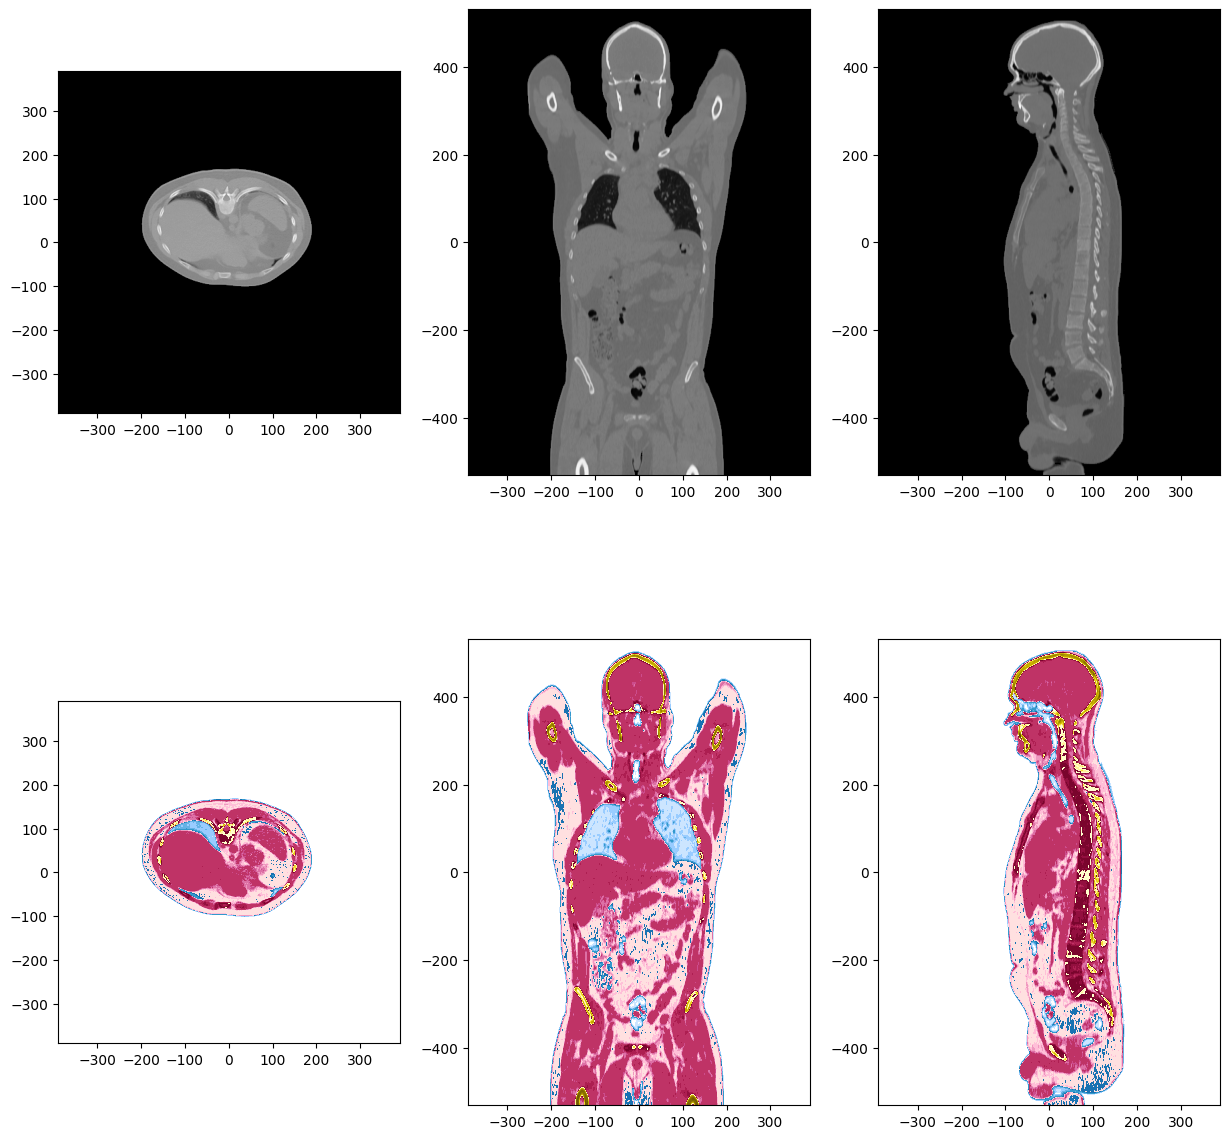

In [6]:
zco, xco, yco = len(zax)//2, len(xax)//2, len(yax)//2
f, axs = plt.subplots(2,3, figsize=(15,15))
axs[0,0].imshow(img_HU[zco,:,:][::-1], cmap="Greys_r", extent=(xax[0], xax[-1], yax[0], yax[-1]))
axs[0,1].imshow(img_HU[:,yco,:][::-1], cmap="Greys_r", extent=(xax[0], xax[-1], zax[0], zax[-1]))
axs[0,2].imshow(img_HU[:,:,xco][::-1], cmap="Greys_r", extent=(yax[0], yax[-1], zax[0], zax[-1]))
axs[1,0].imshow(img_HU[zco,:,:][::-1], cmap=cmap, norm=norm, extent=(xax[0], xax[-1], yax[0], yax[-1]))
axs[1,1].imshow(img_HU[:,yco,:][::-1], cmap=cmap, norm=norm, extent=(xax[0], xax[-1], zax[0], zax[-1]))
axs[1,2].imshow(img_HU[:,:,xco][::-1], cmap=cmap, norm=norm, extent=(yax[0], yax[-1], zax[0], zax[-1]))
plt.show()